# 01_Introduction.ipynb

---

# What Problem Does It Solve?

Elastic Net is a **regularized linear regression algorithm** that combines the ideas of **Ridge Regression (L2 penalty)** and **Lasso Regression (L1 penalty)**.

Its main goal is to solve three common problems in Linear Regression:

### 1. Overfitting

When a model learns the training data too well, including its noise, it performs poorly on unseen data.

Example:

* Training R² = 0.99
* Testing R² = 0.72

This indicates overfitting.

Elastic Net reduces overfitting by penalizing large coefficients.

---

### 2. Multicollinearity

Multicollinearity means two or more features contain nearly the same information.

Example:

| Feature         | Description |
| --------------- | ----------- |
| House Area      | 2000 sq.ft  |
| Number of Rooms | 8           |

Larger houses usually have more rooms.

These features become highly correlated.

Problems caused:

* Unstable coefficients
* Small data changes produce different models
* Harder interpretation

Ridge handles this well.

Elastic Net inherits this advantage.

---

### 3. Automatic Feature Selection

Sometimes many features contribute very little.

Example:

Suppose we have

```
Age
Salary
Height
Weight
ZipCode
FavoriteColor
HairLength
```

Only

```
Age
Salary
Weight
```

may actually affect the prediction.

Lasso can reduce unnecessary coefficients exactly to zero.

Elastic Net also performs feature selection.

---

### Therefore Elastic Net solves

* Overfitting
* Multicollinearity
* Irrelevant features

at the same time.

---

# Why Was It Developed?

Before Elastic Net, two regularization methods already existed.

## Ridge Regression

Penalty:

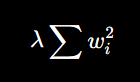

Strengths

* Excellent with correlated features
* Stable coefficients
* Reduces variance

Weakness

* Never removes features.
* Every coefficient remains non-zero.

Example

```
Age          2.1
Salary       5.8
Weight      -0.9
Height       0.0008
Color       -0.0003
```

Even useless features remain.

---

## Lasso Regression

Penalty

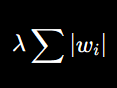

Strength

Removes unnecessary features.

Example

```
Age        2.4
Salary     5.7
Weight    -1.1
Height     0
Color      0
```

Very useful.

Weakness

When features are highly correlated,

Lasso often chooses **one feature** and removes the others.

Example

```
Feature A
Feature B
Feature C
```

All represent almost identical information.

Lasso may keep

```
Feature A
```

and discard

```
Feature B
Feature C
```

Sometimes this is undesirable because all three features may carry useful information.

---

## Elastic Net

Elastic Net combines both penalties.

Instead of choosing only Ridge or only Lasso,

it uses

* L1 penalty
* L2 penalty

together.

So it gains advantages from both.

---

# Real World Applications

Elastic Net is especially useful when datasets contain many features.

---

## 1. Medical Diagnosis

A patient may have

* Blood pressure
* Cholesterol
* Sugar
* BMI
* Heart rate
* Hundreds of genetic markers

Many of these are correlated.

Elastic Net

* selects important variables
* handles correlation
* reduces overfitting

---

## 2. Genomics

Gene datasets often contain

```
Samples = 500

Genes = 20,000
```

Many genes are correlated.

Elastic Net is widely used because

* Ridge alone keeps all genes
* Lasso removes too many correlated genes
* Elastic Net selects groups of relevant genes

---

## 3. Financial Prediction

Predicting

* stock prices
* credit risk
* loan default

using

* income
* debt
* assets
* credit score
* transaction history

Many financial variables are correlated.

Elastic Net performs well in such situations.

---

## 4. Marketing

Predicting

* customer purchases
* churn
* campaign response

using

* age
* income
* browsing history
* purchase history
* advertisement clicks

Many variables overlap.

Elastic Net helps build stable models.

---

## 5. Housing Price Prediction

Features:

```
Area
Bedrooms
Bathrooms
Garage
Living Area
Total Rooms
```

Many are correlated.

Elastic Net reduces overfitting while selecting useful features.

---

# Advantages

### 1. Reduces Overfitting

Like Ridge and Lasso.

---

### 2. Performs Feature Selection

Can set coefficients exactly to zero.

---

### 3. Handles Correlated Features Better than Lasso

Instead of selecting only one feature, Elastic Net often keeps a group of correlated features together.

---

### 4. Produces More Stable Models

Less sensitive to small changes in training data compared to Lasso alone.

---

### 5. Works Well for High-Dimensional Data

Especially when

```
Features >> Samples
```

Example

```
Samples = 300

Features = 5000
```

---

### 6. Flexible

By adjusting hyperparameters, it can behave like:

* Ridge
* Lasso
* A combination of both

---

# Limitations

### 1. More Hyperparameters

Linear Regression

```
None
```

Ridge

```
alpha
```

Lasso

```
alpha
```

Elastic Net

```
alpha
l1_ratio
```

More tuning is required.

---

### 2. Needs Feature Scaling

Since penalties depend on coefficient magnitudes, features should usually be standardized before training.

Typical pipeline:

```
StandardScaler
↓

ElasticNet
```

---

### 3. Still a Linear Model

Elastic Net assumes a linear relationship between features and the target.

If the true relationship is highly nonlinear, it may perform poorly unless combined with techniques such as polynomial features.

---

### 4. Can Underfit

If regularization is too strong (large `alpha`), coefficients shrink excessively, leading to an overly simple model.

---

# Comparison with Previous Algorithms

| Property                    | Linear Regression | Ridge   | Lasso      | Elastic Net         |
| --------------------------- | ----------------- | ------- | ---------- | ------------------- |
| Linear Model                | ✅                 | ✅       | ✅          | ✅                   |
| Reduces Overfitting         | ❌                 | ✅       | ✅          | ✅                   |
| L1 Penalty                  | ❌                 | ❌       | ✅          | ✅                   |
| L2 Penalty                  | ❌                 | ✅       | ❌          | ✅                   |
| Removes Features            | ❌                 | ❌       | ✅          | ✅                   |
| Handles Correlated Features | ❌                 | ✅       | ⚠️ Limited | ✅                   |
| Stable Coefficients         | ❌                 | ✅       | Moderate   | ✅                   |
| Feature Selection           | ❌                 | ❌       | ✅          | ✅                   |
| Hyperparameters             | None              | `alpha` | `alpha`    | `alpha`, `l1_ratio` |

---

## When should you choose Elastic Net over Ridge or Lasso?

Choose **Elastic Net** when:

* Your data contains **many correlated features**.
* You want **automatic feature selection** but don't want correlated features to be discarded too aggressively.
* You need a balance between the stability of Ridge and the sparsity of Lasso.
* You are working with **high-dimensional datasets** (many features relative to the number of samples).
*
---